# Feature Engineering 

This notebooks helps in answering the questions " How can we transform this data into meaningful information for our recommendation system? "

# What is Feature Engineering?

Feature Engineering is the process of creating useful information (features) from raw data that helps a machine learning model learn better.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
movies = pd.read_csv(r"E:\end-to-end-collaborative-filtering-recommendation-system\data\movies.csv")
ratings = pd.read_csv(r"E:\end-to-end-collaborative-filtering-recommendation-system\data\ratings.csv")

In [3]:
# Merge the datasets using  { pd.merge() }

movie_ratings = pd.merge(
    ratings,
    movies,
    on="movieId",
    how="inner",
)

# Why Merge?
## Before merging:

### ratings.csv

userId	    movieId	    rating
"""
Only the movie ID is known.
"""
## After merging:

userId	    movieId	    rating	    title	    genres
"""
Now analysis becomes meaningful because you can see the movie names.
"""

In [4]:
# Merged data analysis

movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres,Primary Genre
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,Comedy
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,Action
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Mystery
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Crime


In [5]:
movie_ratings.shape

(100836, 7)

In [6]:
movie_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   userId         100836 non-null  int64  
 1   movieId        100836 non-null  int64  
 2   rating         100836 non-null  float64
 3   timestamp      100836 non-null  int64  
 4   title          100836 non-null  object 
 5   genres         100836 non-null  object 
 6   Primary Genre  100836 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.4+ MB


In [7]:
# Count the most rated movies

movie_ratings_count = (
    movie_ratings
    .groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    
)

movie_ratings_count.head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

In [8]:
# Highest rated movie

movie_ratings_count = (
    movie_ratings
    .groupby("title")["rating"] 
    .mean()
    .sort_values(ascending=False)
)

movie_ratings_count.head(10)

title
Karlson Returns (1970)                                                         5.0
Zeitgeist: Moving Forward (2011)                                               5.0
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)    5.0
Dragons: Gift of the Night Fury (2011)                                         5.0
12 Angry Men (1997)                                                            5.0
Justice League: Doom (2012)                                                    5.0
Junior and Karlson (1968)                                                      5.0
Jump In! (2007)                                                                5.0
Human Condition III, The (Ningen no joken III) (1961)                          5.0
Louis Theroux: Law & Disorder (2008)                                           5.0
Name: rating, dtype: float64

In [9]:
#Check for active users
ratings["userId"].value_counts().head(10)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
Name: count, dtype: int64

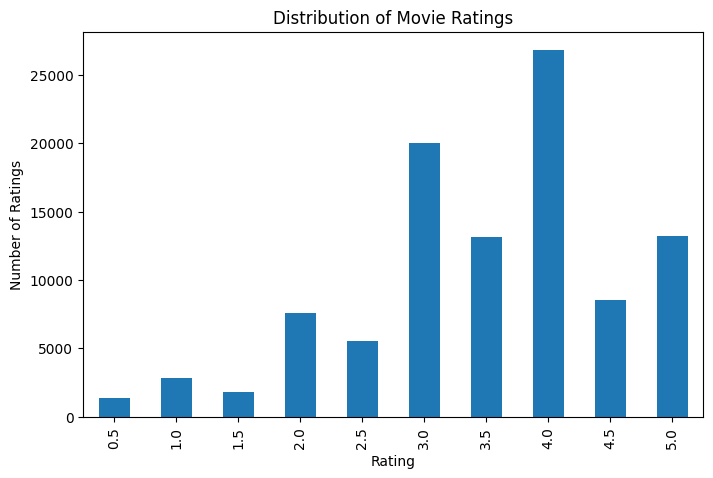

In [10]:
import matplotlib.pyplot as plt

ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

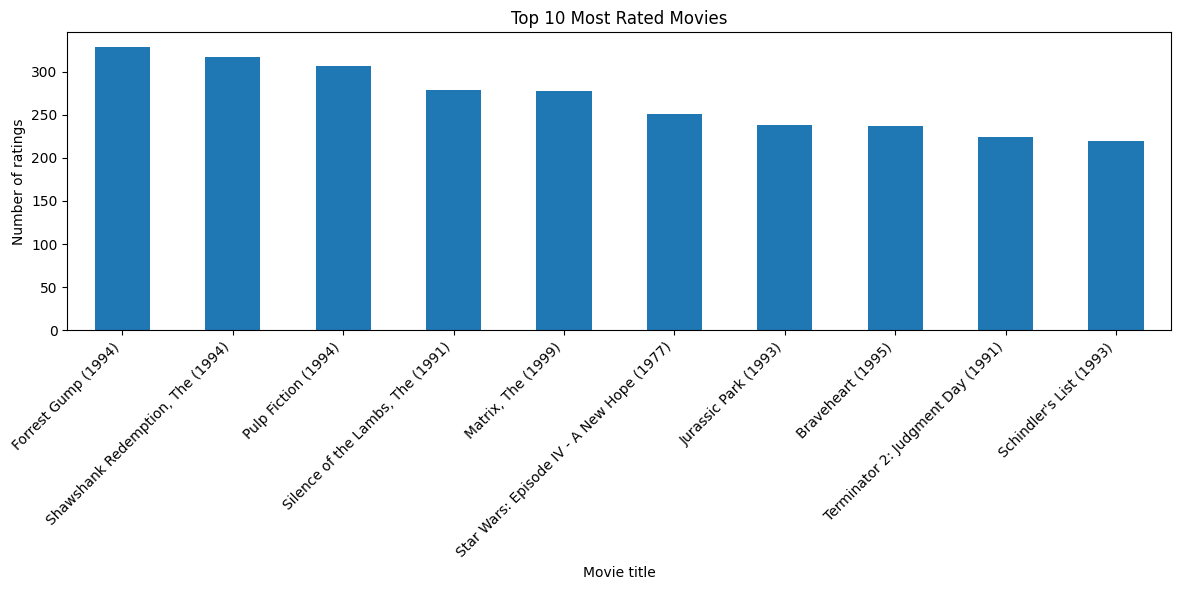

In [31]:
top_movies = (
    movie_ratings
    .groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_movies.plot(
    kind="bar",
    figsize=(12,6),
    colormap="tab10"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie title")
plt.ylabel("Number of ratings")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
#plt.show()

## Observation

The distribution shows that ratings are concentrated between 3 and 4 stars. This indicates that users generally provide moderately positive feedback. Since the dataset is skewed toward higher ratings, the recommendation model may need to account for this bias during evaluation.